In [1]:
# %matplotlib inline

import random
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh

from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from scipy import interpolate
from sklearn.metrics import roc_curve, auc
from cycler import cycler

import uproot ## means uproot4
import awkward as ak
import sklearn.metrics as m


use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

filedict={
    'HWW': '/mldata/licq/deepjetak8/20220625_ak8_UL17_v4/BulkGravitonToHHTo4W_MX-600to6000_MH-15to250_JHUVariableWMass/*/*.root',
    'W_jets': '/mldata/licq/deepjetak8/20220625_ak8_UL17_v4/BulkGravToWWToWhadWhad_narrow_M-500to8000_TuneCP5/*/*.root',
    'Top': '/mldata/licq/deepjetak8/20220625_ak8_UL17_v4/ZprimeToTT_M1200to4500_W12to45_TuneCP2_PSweights/*/*.root',
    #'QCD': '/mldata/licq/deepjetak8/20200601_ak8_UL17_flat/QCD*/*/*/*/output_*.root',
}


events, labels, variables = {sample: {} for sample in filedict}, {sample: set() for sample in filedict}, {sample: set() for sample in filedict}
for sample in events:
    ## optional opening methods: uproot.lazy({ "$FILEPATH": "TTree", ...}) or uproot.lazy(["$FILEPATH:TTree", ...])
    ak_array = uproot.lazy({filedict[sample]: "deepntuplizer/tree"}) ## lazy means lazy computation style
    for var in ak_array.fields:
        if 'label_' in var:
            labels[sample].add(var.replace('score_', '').replace('label_', '')) 
        else:
            variables[sample].add(var)
        events[sample][var.replace('label_', '')] = ak_array[var]

In [11]:
for l in labels['HWW']: 
    x = np.sum(events['HWW'][l])
    if x>0:
        print(l, "%.2g"%x)

H_wwhadtauvqq_0c 1.5e+06
QCD_cc 2.3e+05
H_wwevqq_0c 2.4e+06
H_wwmvqq_1c 2.3e+06
H_ww4q_2c 1.7e+06
H_ww4q_0c 1.7e+06
H_wwevqq_1c 2.3e+06
QCD_bb 6.6e+04
H_ww3q_0c 2.8e+05
H_ww2qsame 1.9e+04
H_ww3q_1c 3.7e+05
QCD_c 5.6e+05
QCD_b 5e+04
H_wwhadtauvqq_1c 1.5e+06
H_ww2qsep 1.7e+05
QCD_others 3.9e+06
H_wwleptauevqq_0c 4e+05
H_ww4q_1c 3.4e+06
H_wwmvqq_0c 2.4e+06
H_wwleptaumvqq_0c 3.9e+05
H_ww3q_2c 9.3e+04
H_wwleptaumvqq_1c 3.8e+05
H_wwleptauevqq_1c 3.9e+05


In [12]:
for l in labels['Top']:
    x = np.sum(events['Top'][l])
    if x>0:
        print(l, "%.2g"%x)

Top_bcq 8e+05
Top_bq 3.6e+05
QCD_cc 4.9e+04
W_qq_b 3.9e+02
W_qq_c 2.3e+03
QCD_bb 2.4e+04
Top_bhadtauv 1.7e+05
W_qq 9.5e+04
W_cq_c 2.3e+03
Top_bc 1.7e+05
Top_bev 2.8e+05
W_cq_b 4e+02
QCD_c 5e+04
Top_bqq 8e+05
QCD_b 1.9e+05
QCD_others 4.2e+05
Top_bmv 2.8e+05
Top_bleptauev 4.5e+04
W_cq 9.3e+04
Top_bleptaumv 4.4e+04


In [13]:
for l in labels['W_jets']:
    x = np.sum(events['W_jets'][l])
    if x>0:
        print(l, "%.2g"%x)

QCD_cc 9.9e+04
W_qq_b 3.2e+04
W_qq_c 1.6e+05
QCD_bb 3e+04
W_qq 5.6e+06
W_cq_c 1.6e+05
W_cq_b 3.2e+04
QCD_c 1.3e+05
QCD_b 2.2e+04
QCD_others 1.9e+06
W_cq 5.5e+06


In [2]:
def mergeClass(tagger, old, new):
    events[tagger][new] = events[tagger].get(new, np.zeros_like(events[tagger][old])) + events[tagger][old]
    #events[tagger]['score_'+new] = events[tagger].get('score_'+new, np.zeros_like(events[tagger]['score_'+old])) + events[tagger]['score_'+old]    

for tagger in events:
    for l in list(labels[tagger]):
        if l.startswith('QCD_'):
            mergeClass(tagger, old=l, new='QCD')
            labels[tagger].add('QCD')
        elif l.startswith('Top_'):
            mergeClass(tagger, old=l, new='Top')
            labels[tagger].add('Top')
        elif l.startswith('H_ww4q'):
            mergeClass(tagger, old=l, new='H_WqqWqq')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWqq')
            labels[tagger].remove(l)
        elif l.startswith('H_ww3q'):
            mergeClass(tagger, old=l, new='H_WqqWq')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWq')
            labels[tagger].remove(l)
        elif l.startswith('H_wwevqq'):
            mergeClass(tagger, old=l, new='H_WqqWev')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWev')
            labels[tagger].remove(l)
        elif l.startswith('H_wwmvqq'):
            mergeClass(tagger, old=l, new='H_WqqWmv')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWmv')
            labels[tagger].remove(l)
        elif l.startswith('H_wwleptauevqq'):
            mergeClass(tagger, old=l, new='H_WqqWtauev')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWtauev')
            labels[tagger].remove(l)
        elif l.startswith('H_wwleptaumvqq'):
            mergeClass(tagger, old=l, new='H_WqqWtaumv')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWtaumv')
            labels[tagger].remove(l)
        elif l.startswith('H_wwhadtauvqq'):
            mergeClass(tagger, old=l, new='H_WqqWtauhv')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('H_WqqWtauhv')
            labels[tagger].remove(l)
        elif l.startswith('W_'):
            mergeClass(tagger, old=l, new='Wqq_jets')
            mergeClass(tagger, old=l, new='HWW')
            labels[tagger].add('Wqq_jets')

In [8]:
def plot(labels, filename, variable, bins=24, x_min=20, x_max=260, density=True, stack=False, colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']):
    ## canvas initializing
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=2017, ax=ax)
    
    
    ## plot
    for sample in labels:
        for l in labels[sample]:
            hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
            var = events[sample][variable][events[sample][l]>0]
            hist.fill(var)
            h, err = hist.view().value, np.sqrt(hist.view().variance)
            hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='XWW' if l=='HWW' else l, histtype='step', density=density, stack=stack)


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.1)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(r'$m_{SD}$', fontsize=20, ha='right', x=1)

    plt.xticks(size=14)
    plt.yticks(size=14)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=1, frameon=False,fontsize=18)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix=''
    if density==True:   suffix+='_AU'
    if stack==True:     suffix+='_stack'
    plt.savefig("plots/"+filename+suffix+".pdf", bbox_inches='tight')
    plt.show()

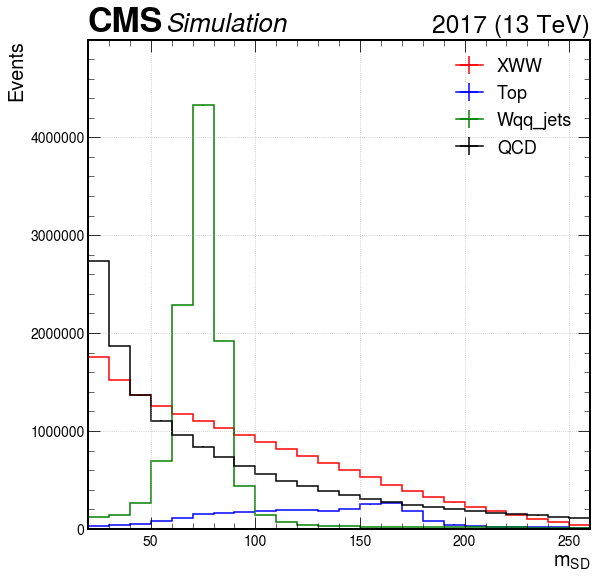

In [9]:
plot(
    labels={'HWW': ['HWW'], #['H_WqqWqq', 'H_WqqWq', 'H_WqqWev', 'H_WqqWmv', 'H_WqqWtauev', 'H_WqqWtaumv', 'H_WqqWtauhv'],
            'Top': ['Top'], #['Top_bc','Top_bcq', 'Top_bev', 'Top_bhadtauv', 'Top_bleptauev' ,'Top_bleptaumv', 'Top_bmv', 'Top_bq', 'Top_bqq'],
            'W_jets': ['Wqq_jets'], #['W_cq_b', 'W_cq_c', 'W_cq', 'W_qq_b', 'W_qq_c', 'W_qq'],
            'QCD': ['QCD'],
            },
    filename='sdmass', variable='fj_sdmass', density=False
)

In [6]:
def plot(labels, filename, variable, bins=12, x_min=200, x_max=2500, density=False, stack=False, colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']):
    ## canvas initializing
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=2017, ax=ax)
    
    
    ## plot
    for sample in labels:
        for l in labels[sample]:
            hist = bh.Histogram(bh.axis.Variable(np.logspace(np.log10(x_min), np.log10(x_max), bins)), storage=bh.storage.Weight())
            var = events[sample][variable][events[sample][l]>0]
            hist.fill(var)
            h, err = hist.view().value, np.sqrt(hist.view().variance)
            hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='XWW' if l=='HWW' else l, histtype='step', density=density, stack=stack)


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.1)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(r'$p_T$', fontsize=20, ha='right', x=1)

    plt.xticks(size=14)
    plt.yticks(size=14)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=1, frameon=False,fontsize=18)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix=''
    if density==True:   suffix+='_AU'
    if stack==True:     suffix+='_stack'
    plt.savefig("plots/"+filename+suffix+".pdf", bbox_inches='tight')
    plt.show()

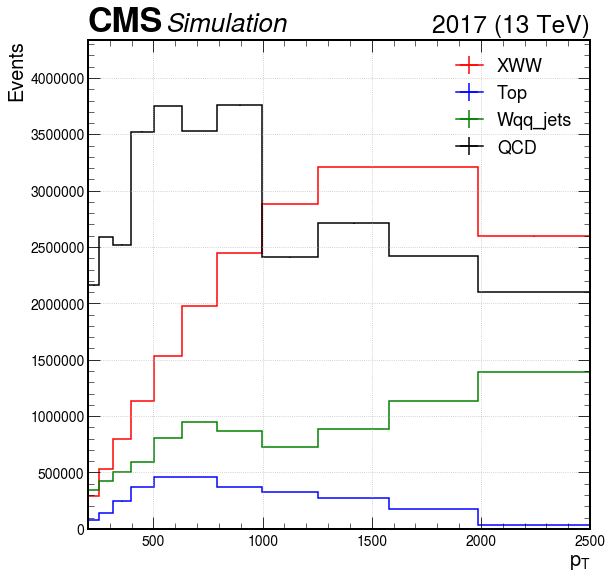

In [7]:
plot(
    labels={'HWW': ['HWW'], #['H_WqqWqq', 'H_WqqWq', 'H_WqqWev', 'H_WqqWmv', 'H_WqqWtauev', 'H_WqqWtaumv', 'H_WqqWtauhv'],
            'Top': ['Top'], #['Top_bc','Top_bcq', 'Top_bev', 'Top_bhadtauv', 'Top_bleptauev' ,'Top_bleptaumv', 'Top_bmv', 'Top_bq', 'Top_bqq'],
            'W_jets': ['Wqq_jets'], #['W_cq_b', 'W_cq_c', 'W_cq', 'W_qq_b', 'W_qq_c', 'W_qq'],
            'QCD': ['QCD'],
            },
    filename='pt', variable='fj_pt',
)

In [ ]:
def samples_distribution(samples, labels, variable, bins=20, x_min=0, x_max=100, density=False, stack=False, colorlist=colorlist):
    ## canvas initializing
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=2017, ax=ax)
    

    ## plot
    for i in range(len(samples)):
        sample=samples[i]
        if variable=='fj_pt':
            hist = bh.Histogram(bh.axis.Variable(np.logspace(np.log10(x_min), np.log10(x_max), bins)), storage=bh.storage.Weight())
        elif variable=='fj_gen_mass' and len(samples)==1:    
            hist = bh.Histogram(bh.axis.Regular(bins*4, x_min, x_max), storage=bh.storage.Weight())
        else:
            hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())

        if sample=='QCD' and variable=='fj_gen_mass':
            hist.fill(events[sample]['fj_genjet_sdmass'][truth_matched[sample]['matched']])
        elif sample=='QCD' and variable=='m_hybrid':
            hist.fill(events[sample]['fj_sdmass'][truth_matched[sample]['matched']])
        elif sample=='signal' and variable=='m_hybrid':
            hist.fill(events[sample]['fj_gen_mass'][truth_matched[sample]['matched']])
        else:
            hist.fill(events[sample][variable][truth_matched[sample]['matched']])

        h, err = hist.view().value, np.sqrt(hist.view().variance)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=labels[i], histtype='step', density=density, stack=stack)


    ## axises
    if x_min and x_max:
        plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.1)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if variable=='fj_gen_mass':
        plt.xlabel(r'$m^{gen}$ [GeV]', fontsize=20, ha='right', x=1)
    elif variable=='fj_sdmass':
        plt.xlabel(r'$m_{SD}$ [GeV]', fontsize=20, ha='right', x=1)
    elif variable=='fj_pt':
        plt.xlabel(r'$p_{T}$ [GeV]', fontsize=20, ha='right', x=1)
    elif variable=='m_hybrid':
        plt.xlabel(r'$m_{hybrid}$ [GeV]', fontsize=20, ha='right', x=1)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)

    plt.xticks(size=14)
    plt.yticks(size=14)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=3, frameon=False,fontsize=20)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix=''
    if density==True:   suffix+='_AU'
    if stack==True:     suffix+='_stack'
    plt.savefig("plots/samples_"+variable+suffix+".pdf", bbox_inches='tight')
    plt.show()



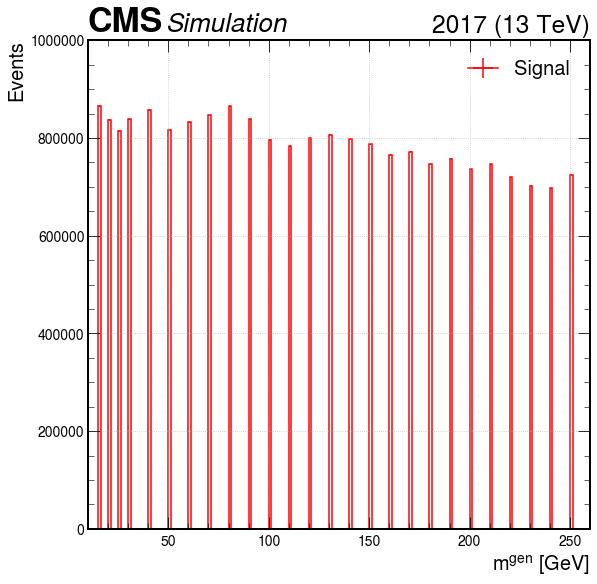

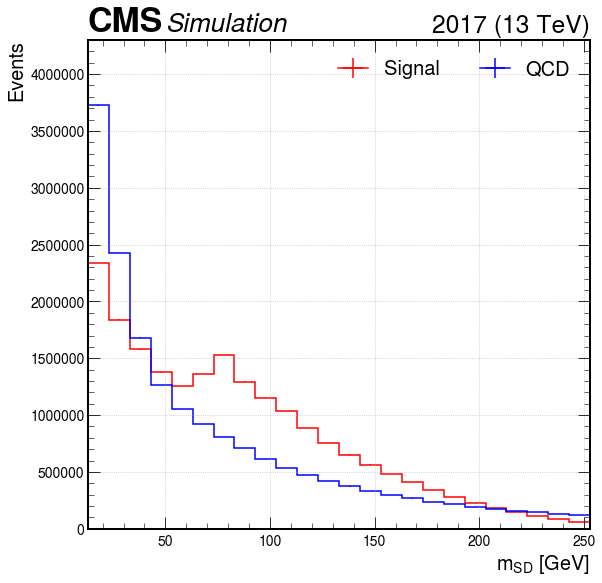

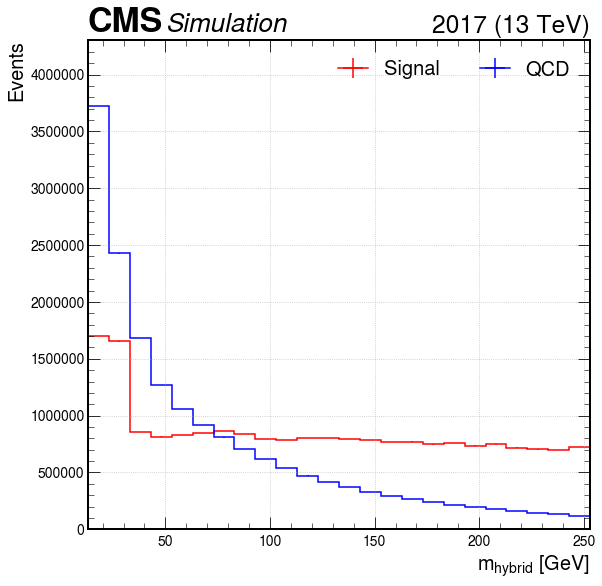

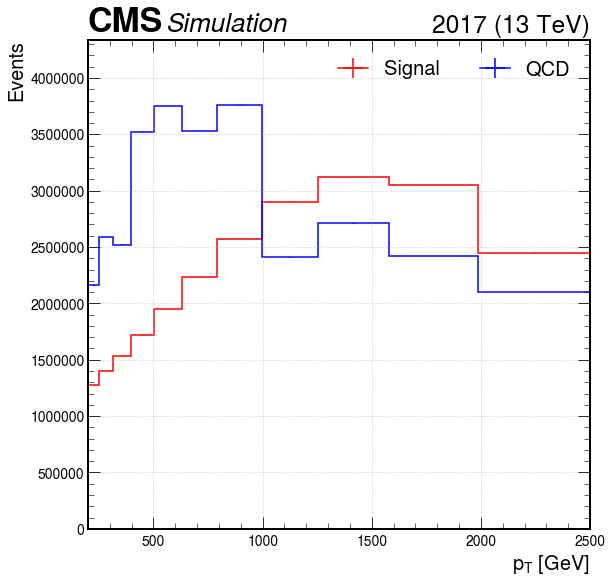

In [5]:
samples_distribution(samples=['signal'],labels=['Signal'],variable='fj_gen_mass',density=False)
samples_distribution(samples=['signal','QCD'],labels=['Signal','QCD'],variable='fj_sdmass',bins=24, x_min=13, x_max=253)
#samples_distribution(samples=['signal','QCD'],labels=['Signal','QCD'],variable='fj_gen_mass',bins=24, x_min=13, x_max=253)
samples_distribution(samples=['signal','QCD'],labels=['Signal','QCD'],variable='m_hybrid',bins=24, x_min=13, x_max=253)
samples_distribution(samples=['signal','QCD'],labels=['Signal','QCD'],variable='fj_pt',bins=12, x_min=200, x_max=2500)

In [1]:
def components_distribution(sample, variable, Higgsmass='all', colorlist=colorlist, bins=48, x_min=10, x_max=250,density=False, stack=False):
    labels=label[sample]

    ## canvas initializing
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=2017, ax=ax)

    ## plot
    for component in labels.keys():
        if component=='unmatch': continue
        if Higgsmass=='all':
            selection=(truth_matched[sample][component])
        else:
            selection=(events[sample]['fj_gen_mass']==Higgsmass)*(truth_matched[sample][component])
        component_var = events[sample][variable][selection]
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        hist.fill(component_var)
        height, err = hist.view().value, np.sqrt(hist.view().variance)

        hep.histplot(height, bins=hist.axes[0].edges, yerr=err, label=LaTeX_label[sample][component], density=density, stack=stack, histtype='step')


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.2)
    #x_major_locator=plt.MultipleLocator(10)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if variable=='fj_pt':
        plt.xlabel(r'$p_{T}$ [GeV]', fontsize=20, ha='right', x=1)
    else:
        plt.xlabel(r'$m_{SD}$ [GeV]', fontsize=20, ha='right', x=1)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xticks(size=14)
    plt.yticks(size=14)

    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="upper right", ncol=3, frameon=False,fontsize=18)
    if Higgsmass!='all':
        plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.54,r"400GeV$<p_T<$600GeV, $|\eta|<2.4$", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix=''
    if density==True:   suffix+='_AU'
    if stack==True:     suffix+='_stack'
    plt.savefig(f"plots/{sample}_{variable}"+suffix+".pdf", bbox_inches='tight')
    plt.show()


NameError: name 'colorlist' is not defined

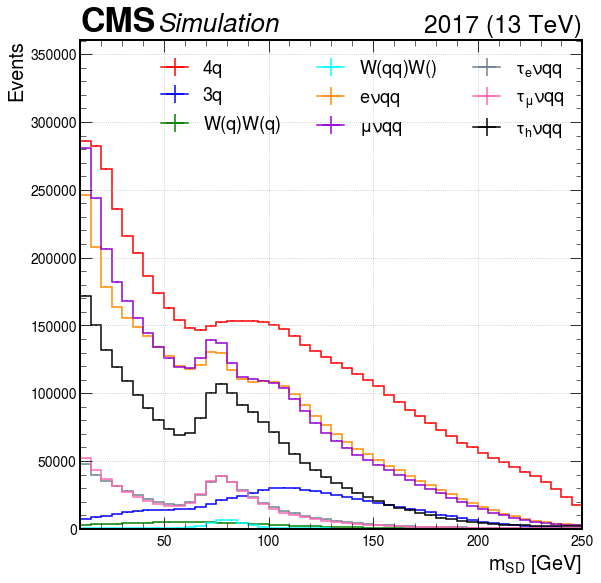

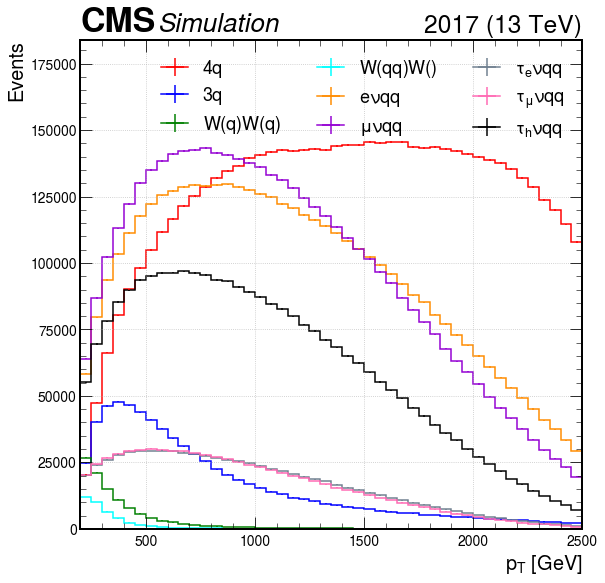

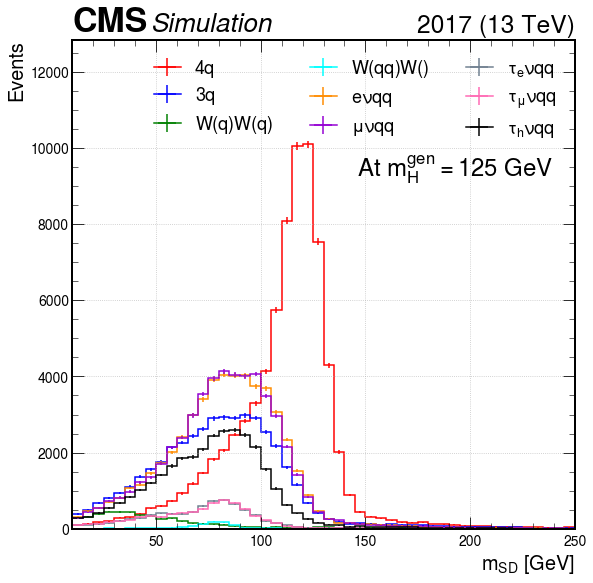

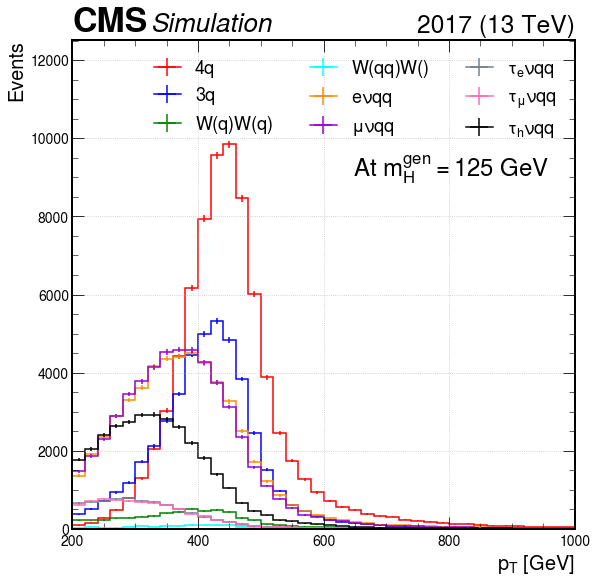

In [18]:
components_distribution(sample='signal',variable='fj_sdmass',Higgsmass='all',bins=48,x_min=10,x_max=250)
components_distribution(sample='signal',variable='fj_pt',Higgsmass='all',bins=46, x_min=200, x_max=2500)
components_distribution(sample='inference_signal',variable='fj_sdmass',Higgsmass=125,bins=48,x_min=10,x_max=250)
components_distribution(sample='inference_signal',variable='fj_pt',Higgsmass=125,bins=40, x_min=200, x_max=1000)

In [ ]:
gen_mass=set(events['signal']['fj_gen_mass'])
gen_mass=list(gen_mass)